<a href="https://colab.research.google.com/github/sanchezmicaela/Aprendizaje_Automatico/blob/main/4-modelos_supervisados_2-micaela-sanchez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Datos del Estudiante**

Nombre:Micaela Arami Sánchez Arce

CI:5572584

# **Clase 4 — Modelos Supervisados II: SVM y Redes Neuronales (MLP)**

**Objetivos**
- Comprender modelos no lineales potentes: SVM (kernels) y MLP (redes neuronales multicapa).
- Ver la formulación matemática esencial y las decisiones de optimización.
- Implementar y comparar SVM (RBF) y MLP con `scikit-learn`.
- Visualizar fronteras de decisión en datasets no lineales (moons, circles).
- Realizar ejercicios prácticos y análisis de hiperparámetros.


## **Imports y configuración inicial**

In [ ]:
# Imports básicos
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# Crear carpeta para guardar figuras
os.makedirs('figures', exist_ok=True)


## **Funciones auxiliares: plot de frontera y utilidades**

Usa la función de explicar codigo. Explica con tus palabras para que sierve la función plot_decision_boundary.

In [ ]:
def plot_decision_boundary(clf, X, y, ax=None, title=None, cmap='coolwarm', proba=False):
    """
    Dibuja la frontera de decisión de un clasificador entrenado.
    - clf: clasificador (debe tener predict o predict_proba/decision_function)
    - X: array (n_samples, 2)
    - y: etiquetas
    - ax: matplotlib axis opcional
    - proba: si True intenta usar predict_proba para contornos
    """
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
    y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    try:
        if proba and hasattr(clf, "predict_proba"):
            Z = clf.predict_proba(grid)[:,1]
            Z = Z.reshape(xx.shape)
            cs = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.4)
        else:
            Z = clf.predict(grid)
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    except Exception:
        # fallback: usar decision_function si existe
        if hasattr(clf, "decision_function"):
            Z = clf.decision_function(grid)
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z > 0, alpha=0.3, cmap=cmap)
        else:
            raise
    ax.scatter(X[:,0], X[:,1], c=y, s=30, edgecolor='k', cmap=cmap)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    if title:
        ax.set_title(title)

def save_figure(fig, fname):
    path = os.path.join('figures', fname)
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f"Saved {path}")


## **Generar datasets no lineales (moons y circles)**

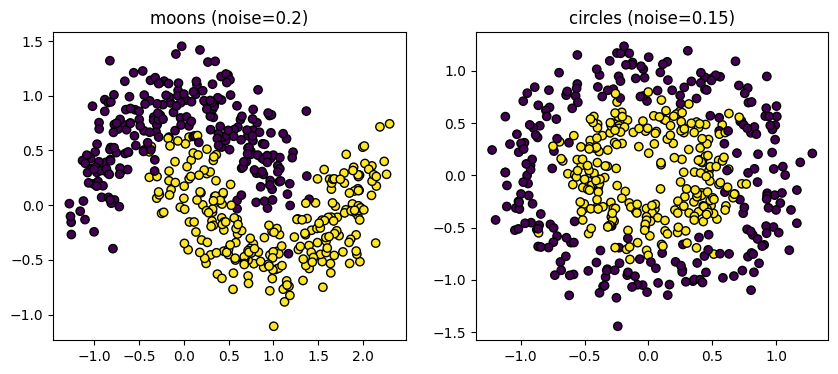

In [ ]:
# Dataset: moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=0)

# Dataset: circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.15, factor=0.5, random_state=1)

# Mostrar ejemplos
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X_moons[:,0], X_moons[:,1], c=y_moons, edgecolor='k')
axes[0].set_title('moons (noise=0.2)')
axes[1].scatter(X_circles[:,0], X_circles[:,1], c=y_circles, edgecolor='k')
axes[1].set_title('circles (noise=0.15)')
plt.show()


> Consulta en la notebookLM sobre las funciones make_moons, make_circles, make_classification y explica en que se diferencian:

## **Entrenamiento y visualización: moons (SVM vs MLP)**

Moons - SVM acc: 0.94
Moons - MLP acc: 0.9533333333333334
Saved figures/svm_moons_vs_mlp_moons.png


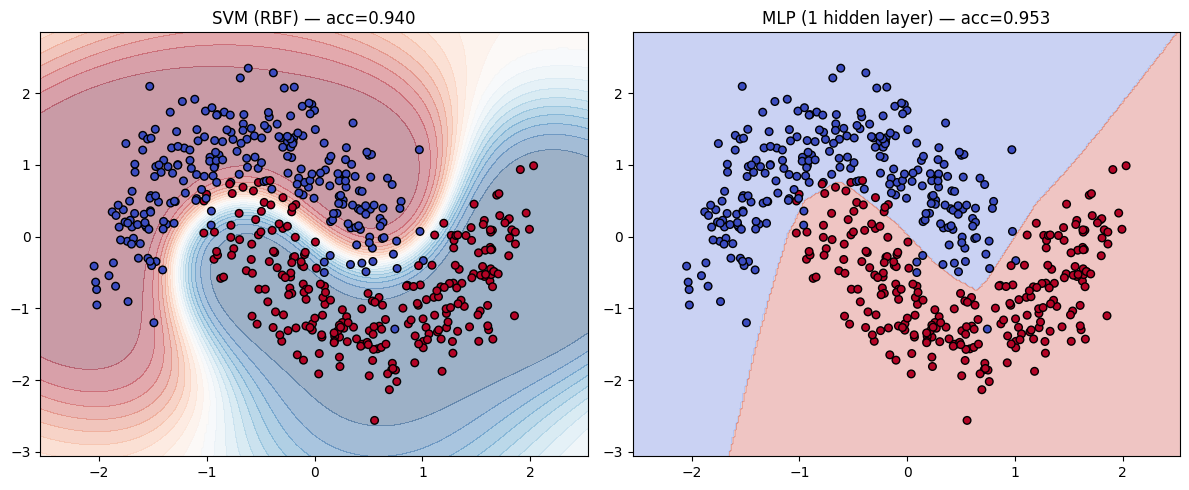

In [ ]:
# Preparar datos (train/test + escalado)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)
scaler_m = StandardScaler().fit(X_train_m)
X_train_m_s = scaler_m.transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)
X_moons_s = scaler_m.transform(X_moons)

# Modelos
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_moons = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenar
svm_rbf.fit(X_train_m_s, y_train_m)
mlp_moons.fit(X_train_m_s, y_train_m)

# Evaluar
pred_svm_m = svm_rbf.predict(X_test_m_s)
pred_mlp_m = mlp_moons.predict(X_test_m_s)
print("Moons - SVM acc:", accuracy_score(y_test_m, pred_svm_m))
print("Moons - MLP acc:", accuracy_score(y_test_m, pred_mlp_m))

# Plot y guardar
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_decision_boundary(svm_rbf, X_moons_s, y_moons, ax=axes[0], title=f"SVM (RBF) — acc={accuracy_score(y_test_m, pred_svm_m):.3f}", proba=True)
plot_decision_boundary(mlp_moons, X_moons_s, y_moons, ax=axes[1], title=f"MLP (1 hidden layer) — acc={accuracy_score(y_test_m, pred_mlp_m):.3f}")
plt.tight_layout()
save_figure(fig, 'svm_moons_vs_mlp_moons.png')
plt.show()


> Respoden entre lineas

1.   Qué función cumple el parámetro C en SVC?
2.   Cómo afecta el hiperparametro degree al modelo de SVC?
3.   Qué otras funciones de activación permite la función MLPClassifier?
4.   Cómo afecta el solver sgd al MLPClassifier en su exactitud? Solicita ayuda al chatbot de la notebookLM para entender las diferencias en la exactitud al cambiar el solver de adam a sgd.  





## **Guardar modelos y artefactos**

Usa la función de explicar codigo y explica con tus palabras la utilidad de su implementación

In [ ]:
joblib.dump(svm_rbf, 'figures/svm_moons_model.joblib')
joblib.dump(mlp_moons, 'figures/mlp_moons_model.joblib')
joblib.dump(scaler_m, 'figures/scaler_moons.joblib')

# Preparar datos (train/test + escalado) para circles
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.3, random_state=42)
scaler_c = StandardScaler().fit(X_train_c)
X_train_c_s = scaler_c.transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# Modelos para circles
svm_rbf_c = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_circles = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenar modelos para circles
svm_rbf_c.fit(X_train_c_s, y_train_c)
mlp_circles.fit(X_train_c_s, y_train_c)

joblib.dump(svm_rbf_c, 'figures/svm_circles_model.joblib')
joblib.dump(mlp_circles, 'figures/mlp_circles_model.joblib')
joblib.dump(scaler_c, 'figures/scaler_circles.joblib')

print("Modelos y scalers guardados en carpeta 'figures'.")

Modelos y scalers guardados en carpeta 'figures'.


## **Ejemplo de Carga y Uso de Modelos Guardados**

In [ ]:
print('--- Ejemplo de Carga y Uso de Modelos Guardados ---\n')

# 1. Cargar el modelo y el scaler
loaded_svm_moons = joblib.load('figures/svm_moons_model.joblib')
loaded_scaler_moons = joblib.load('figures/scaler_moons.joblib')

print('Modelos y scalers cargados exitosamente.\n')

# 2. Generar un nuevo punto de datos para predecir (o tomar uno del conjunto de prueba)
# Usaremos un punto de X_test_m para demostrar la funcionalidad
new_data_point_original = X_test_m[0].reshape(1, -1) # reshape para que sea 2D

print(f'Punto de datos original para predecir: {new_data_point_original[0]}\n')

# 3. Escalar el nuevo punto de datos usando el scaler cargado
new_data_point_scaled = loaded_scaler_moons.transform(new_data_point_original)

print(f'Punto de datos escalado: {new_data_point_scaled[0]}\n')

# 4. Realizar una predicción con el modelo cargado
prediction = loaded_svm_moons.predict(new_data_point_scaled)

print(f'La predicción del modelo cargado para este punto es: {prediction[0]}\n')

# Para verificar, comparemos con la etiqueta real (si es conocida)
actual_label = y_test_m[0]
print(f'La etiqueta real (conocida) para este punto es: {actual_label}\n')

if prediction[0] == actual_label:
    print('¡La predicción coincide con la etiqueta real!')
else:
    print('La predicción NO coincide con la etiqueta real.')


--- Ejemplo de Carga y Uso de Modelos Guardados ---

Modelos y scalers cargados exitosamente.

Punto de datos original para predecir: [ 1.09250531 -0.37335468]

Punto de datos escalado: [ 0.65767012 -1.15397239]

La predicción del modelo cargado para este punto es: 1

La etiqueta real (conocida) para este punto es: 1

¡La predicción coincide con la etiqueta real!


## **Visualizaciones separadas (guardar SVM y MLP por separado)**

In [ ]:
# Si prefieres archivos separados por modelo, generarlos así:

X_circles_s = scaler_c.transform(X_circles)

# Moons: SVM
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(svm_rbf, X_moons_s, y_moons, ax=ax, title="SVM (RBF) — moons", proba=True)
save_figure(fig, 'svm_moons.png')
plt.close(fig)

# Moons: MLP
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(mlp_moons, X_moons_s, y_moons, ax=ax, title="MLP (1 hidden layer) — moons")
save_figure(fig, 'mlp_moons.png')
plt.close(fig)

# Circles: SVM
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(svm_rbf_c, X_circles_s, y_circles, ax=ax, title="SVM (RBF) — circles", proba=True)
save_figure(fig, 'svm_circles.png')
plt.close(fig)

# Circles: MLP
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(mlp_circles, X_circles_s, y_circles, ax=ax, title="MLP (2 hidden layers) — circles")
save_figure(fig, 'mlp_circles.png')
plt.close(fig)


Saved figures/svm_moons.png
Saved figures/mlp_moons.png
Saved figures/svm_circles.png
Saved figures/mlp_circles.png


## **Análisis de sensibilidad a hiperparámetros**

In [ ]:
# Ejemplo: variar C y gamma en SVM (moons) y observar accuracy en test
from itertools import product

Cs = [0.1, 1, 10]
gammas = ['scale', 0.5, 1.0]
results = []

for C, g in product(Cs, gammas):
    clf = SVC(kernel='rbf', C=C, gamma=g, random_state=42)
    clf.fit(X_train_m_s, y_train_m)
    acc = accuracy_score(y_test_m, clf.predict(X_test_m_s))
    results.append((C, g, acc))

import pandas as pd
df_res = pd.DataFrame(results, columns=['C','gamma','acc'])
print(df_res.pivot(index='C', columns='gamma', values='acc'))


gamma       0.5       1.0     scale
C                                  
0.1    0.906667  0.933333  0.906667
1.0    0.940000  0.960000  0.940000
10.0   0.966667  0.966667  0.966667


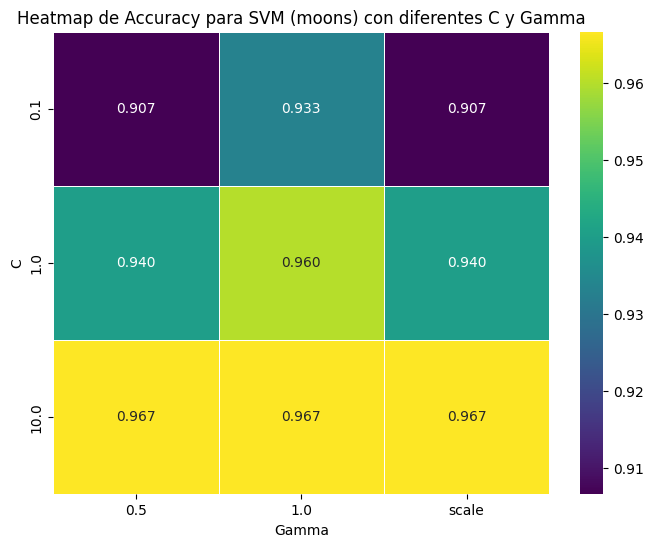

In [ ]:
import seaborn as sns

# Preparar los datos para el heatmap
# El dataframe df_res ya tiene los resultados de la sensibilidad
# lo pivotamos como se hizo antes para el print
heatmap_data = df_res.pivot(index='C', columns='gamma', values='acc')

# Crear el heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('Heatmap de Accuracy para SVM (moons) con diferentes C y Gamma')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()


> Interpreta los resultados del analisis de sensibilidad a hiperparámetros:

# **Ejercicios prácticos**

1. **Explorar hiperparámetros SVM**
   - En el dataset `moons`, haga una búsqueda en cuadrícula (GridSearchCV) sobre `C` y `gamma`.
   - Reporte la mejor combinación y compare la frontera resultante con la frontera por defecto.

2. **Arquitectura MLP**
   - En `circles`, pruebe distintas arquitecturas: una capa oculta con 50, 100, 200 unidades; dos capas con (50,50), (100,50), (100,100).
   - Compare accuracy y tiempos de entrenamiento. ¿Qué arquitectura generaliza mejor?

3. **Regularización y early stopping**
   - Active `early_stopping=True` en `MLPClassifier` y compare la convergencia y la generalización.
   - Añada `alpha` (regularización L2) y observe su efecto.

4. **Visualización y PCA**
   - Si dispone de un dataset con más de 2 atributos, aplique PCA a 2 componentes y visualice las fronteras de decisión de SVM y MLP en el espacio proyectado.

5. **Comparación cuantitativa**
   - Para ambos datasets, calcule matriz de confusión y reporte precision/recall/F1 para SVM y MLP.
   - Discuta en qué regiones del espacio cada modelo comete más errores.

6. **Actividad avanzada (opcional)**
   - Implementar un perceptrón multicapa simple (forward + backprop) desde cero para un dataset 2D y comparar su frontera con `MLPClassifier`.


# **Recursos y lecturas recomendadas**

- Cristianini, N. & Shawe-Taylor, J. — *An Introduction to Support Vector Machines and Other Kernel-based Learning Methods*.
- Goodfellow, I., Bengio, Y., Courville, A. — *Deep Learning* (capítulos introductorios sobre MLP y optimización).
- Documentación scikit-learn: `SVC`, `MLPClassifier`, `GridSearchCV`.
- Notebooks de ejemplo en la galería de scikit-learn (datasets y visualizaciones).


# Rúbrica de Evaluación

| Criterio | Descripción | Puntos |
|---|---:|---:|
| Implementación correcta | Código que entrena SVM y MLP según instrucciones y produce resultados reproducibles | **30** |
| Visualizaciones | Fronteras de decisión claras, bien etiquetadas y guardadas como PNG | **20** |
| Análisis de resultados | Interpretación de accuracy, matriz de confusión y discusión de diferencias entre modelos | **15** |
| Experimentos de hiperparámetros | Búsqueda/variación de hiperparámetros y resumen de hallazgos (tablas/plots) | **10** |
| Calidad del código | Legibilidad, comentarios, uso de funciones y buenas prácticas (scaling, seed) | **10** |
| Reproducibilidad y artefactos | Modelos y scalers guardados; instrucciones claras para reproducir y exportar figuras | **10** |
| Entrega y presentación | Notebook ordenado, celdas ejecutables, resultados exportados y breve informe final | **5** |

**Total: 100 puntos**

**Escala sugerida**
- 90–100: Excelente
- 75–89: Bueno
- 60–74: Aceptable
- <60: Insuficiente



## Ejercicio 1

In [6]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_m, y_m = make_moons(
    n_samples=500,
    noise=0.3,
    random_state=42
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m,
    y_m,
    test_size=0.3,
    random_state=42
)

scaler_m = StandardScaler()

X_train_m_s = scaler_m.fit_transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)

print(X_train_m_s.shape)
print(X_test_m_s.shape)

(350, 2)
(150, 2)


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.5, 1]
}

grid_svm = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_m_s, y_train_m)

print("Mejores parámetros:", grid_svm.best_params_)
print("Mejor accuracy de validación:", grid_svm.best_score_)

Mejores parámetros: {'C': 1, 'gamma': 1}
Mejor accuracy de validación: 0.9257142857142858


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_default = SVC(
    kernel="rbf",
    random_state=42
)

svm_default.fit(
    X_train_m_s,
    y_train_m
)

pred_svm_m = svm_default.predict(
    X_test_m_s
)

print(
    "Accuracy SVM por defecto:",
    accuracy_score(y_test_m, pred_svm_m)
)

Accuracy SVM por defecto: 0.9066666666666666


In [9]:
best_svm = grid_svm.best_estimator_

pred_best_svm = best_svm.predict(X_test_m_s)

acc_svm_default = accuracy_score(
    y_test_m,
    pred_svm_m
)

acc_svm_best = accuracy_score(
    y_test_m,
    pred_best_svm
)

print("Accuracy SVM por defecto:", acc_svm_default)
print("Accuracy SVM ajustado:", acc_svm_best)

Accuracy SVM por defecto: 0.9066666666666666
Accuracy SVM ajustado: 0.9


In [11]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

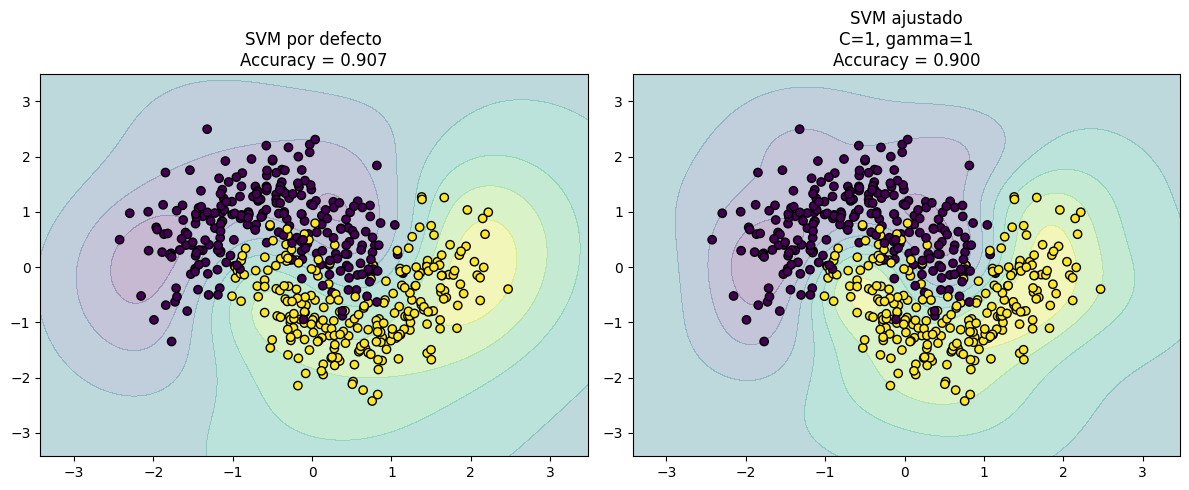

In [12]:
from sklearn.inspection import DecisionBoundaryDisplay

X_m_s = scaler_m.transform(X_m)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

DecisionBoundaryDisplay.from_estimator(
    svm_default,
    X_m_s,
    ax=axes[0],
    alpha=0.3
)

axes[0].scatter(
    X_m_s[:, 0],
    X_m_s[:, 1],
    c=y_m,
    edgecolor="k"
)

axes[0].set_title(
    f"SVM por defecto\nAccuracy = {acc_svm_default:.3f}"
)

DecisionBoundaryDisplay.from_estimator(
    best_svm,
    X_m_s,
    ax=axes[1],
    alpha=0.3
)

axes[1].scatter(
    X_m_s[:, 0],
    X_m_s[:, 1],
    c=y_m,
    edgecolor="k"
)

axes[1].set_title(
    f"SVM ajustado\nC=1, gamma=1\nAccuracy = {acc_svm_best:.3f}"
)

plt.tight_layout()
plt.savefig(
    "comparacion_svm_default_ajustado.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

### Interpretación del Ejercicio 1

*La búsqueda en cuadrícula identificó como mejor combinación los parámetros C=1 y gamma=1, alcanzando una exactitud promedio de validación cruzada de 0.9257.*

*Sin embargo, al evaluar ambos modelos sobre el conjunto de prueba, el SVM por defecto obtuvo una exactitud de 0.907, mientras que el modelo ajustado alcanzó 0.900. Esta diferencia muestra que una mejora observada durante la validación cruzada no siempre se refleja exactamente en una partición específica de prueba.*

*Las fronteras de decisión obtenidas son similares, aunque el modelo ajustado presenta una separación ligeramente más adaptada a la estructura del conjunto de datos.*

## Ejercicio 2

In [13]:
import time
import pandas as pd

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Dataset circles
X_c, y_c = make_circles(
    n_samples=500,
    noise=0.15,
    factor=0.5,
    random_state=42
)

# División de datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size=0.3,
    random_state=42,
    stratify=y_c
)

# Estandarización
scaler_c = StandardScaler()

X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# Arquitecturas solicitadas
arquitecturas = [
    (50,),
    (100,),
    (200,),
    (50, 50),
    (100, 50),
    (100, 100)
]

resultados_mlp = []

for arquitectura in arquitecturas:
    inicio = time.perf_counter()

    modelo = MLPClassifier(
        hidden_layer_sizes=arquitectura,
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    modelo.fit(X_train_c_s, y_train_c)

    fin = time.perf_counter()

    predicciones = modelo.predict(X_test_c_s)
    accuracy = accuracy_score(y_test_c, predicciones)
    tiempo = fin - inicio

    resultados_mlp.append({
        "Arquitectura": str(arquitectura),
        "Accuracy": accuracy,
        "Tiempo_entrenamiento_seg": tiempo,
        "Iteraciones": modelo.n_iter_
    })

df_mlp = pd.DataFrame(resultados_mlp)

df_mlp = df_mlp.sort_values(
    by=["Accuracy", "Tiempo_entrenamiento_seg"],
    ascending=[False, True]
).reset_index(drop=True)

df_mlp

,Arquitectura,Accuracy,Tiempo_entrenamiento_seg,Iteraciones
0,"(50,)",0.940000,2.338123,729
1,"(50, 50)",0.926667,1.000791,293
2,"(100,)",0.926667,1.430038,597
3,"(200,)",0.926667,1.618197,493
4,"(100, 50)",0.926667,3.067419,232
5,"(100, 100)",0.920000,2.645738,230


In [14]:
mejor_fila = df_mlp.iloc[0]

print("Mejor arquitectura:", mejor_fila["Arquitectura"])
print("Accuracy:", round(mejor_fila["Accuracy"], 4))
print(
    "Tiempo de entrenamiento:",
    round(mejor_fila["Tiempo_entrenamiento_seg"], 4),
    "segundos"
)

Mejor arquitectura: (50,)
Accuracy: 0.94
Tiempo de entrenamiento: 2.3381 segundos


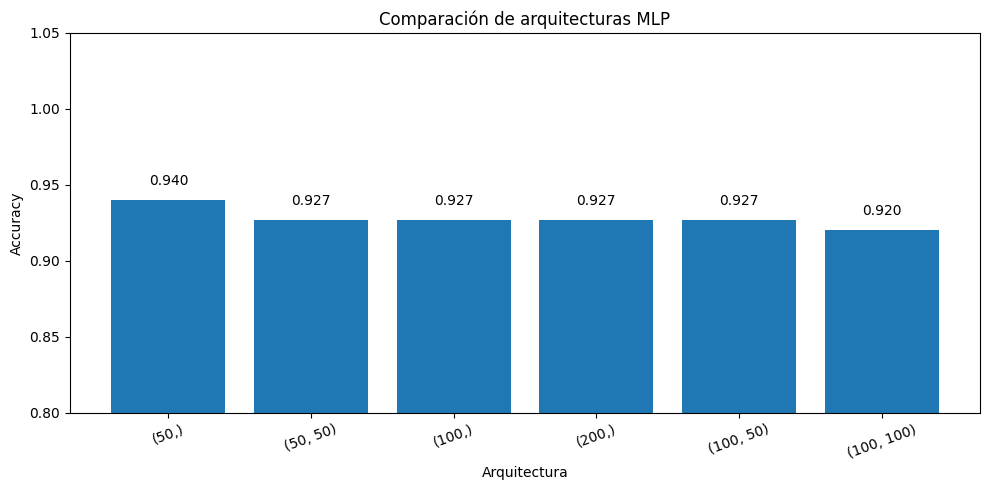

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_mlp["Arquitectura"],
    df_mlp["Accuracy"]
)

plt.ylim(0.8, 1.05)
plt.xlabel("Arquitectura")
plt.ylabel("Accuracy")
plt.title("Comparación de arquitecturas MLP")

plt.xticks(rotation=20)

for i, valor in enumerate(df_mlp["Accuracy"]):
    plt.text(
        i,
        valor + 0.01,
        f"{valor:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "comparacion_arquitecturas_mlp.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Interpretación del Ejercicio 2

Se evaluaron distintas arquitecturas de redes neuronales MLP sobre el dataset circles.

La arquitectura con una sola capa oculta de 50 neuronas obtuvo el mejor desempeño, alcanzando un accuracy de 0.94 sobre el conjunto de prueba.

Las arquitecturas más complejas no mejoraron el rendimiento y, en algunos casos, aumentaron el tiempo de entrenamiento. Esto sugiere que el problema puede resolverse adecuadamente con una red relativamente simple, sin necesidad de incrementar significativamente el número de neuronas o capas ocultas.

Por lo tanto, la arquitectura (50,) presenta la mejor capacidad de generalización entre las configuraciones evaluadas.

## Ejercicio 3

In [16]:
import time
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

configuraciones = [
    {
        "Nombre": "MLP base",
        "early_stopping": False,
        "alpha": 0.0001
    },
    {
        "Nombre": "MLP con early stopping",
        "early_stopping": True,
        "alpha": 0.0001
    },
    {
        "Nombre": "MLP con alpha=0.01",
        "early_stopping": False,
        "alpha": 0.01
    },
    {
        "Nombre": "MLP con early stopping y alpha=0.01",
        "early_stopping": True,
        "alpha": 0.01
    }
]

resultados_ej3 = []

for config in configuraciones:
    inicio = time.perf_counter()

    modelo = MLPClassifier(
        hidden_layer_sizes=(50,),
        activation="relu",
        solver="adam",
        max_iter=1000,
        early_stopping=config["early_stopping"],
        alpha=config["alpha"],
        random_state=42
    )

    modelo.fit(X_train_c_s, y_train_c)

    fin = time.perf_counter()

    predicciones = modelo.predict(X_test_c_s)

    resultados_ej3.append({
        "Modelo": config["Nombre"],
        "Accuracy": accuracy_score(y_test_c, predicciones),
        "Iteraciones": modelo.n_iter_,
        "Tiempo_segundos": fin - inicio
    })

df_ej3 = pd.DataFrame(resultados_ej3)

df_ej3

,Modelo,Accuracy,Iteraciones,Tiempo_segundos
0,MLP base,0.940000,729,2.249389
1,MLP con early stopping,0.786667,60,0.320118
2,MLP con alpha=0.01,0.940000,711,1.226701
3,MLP con early stopping y alpha=0.01,0.786667,60,0.194600


In [17]:
mejor_ej3 = df_ej3.sort_values(
    by=["Accuracy", "Tiempo_segundos"],
    ascending=[False, True]
).iloc[0]

print("Mejor configuración:", mejor_ej3["Modelo"])
print("Accuracy:", round(mejor_ej3["Accuracy"], 4))
print("Iteraciones:", int(mejor_ej3["Iteraciones"]))
print(
    "Tiempo:",
    round(mejor_ej3["Tiempo_segundos"], 4),
    "segundos"
)

Mejor configuración: MLP con alpha=0.01
Accuracy: 0.94
Iteraciones: 711
Tiempo: 1.2267 segundos


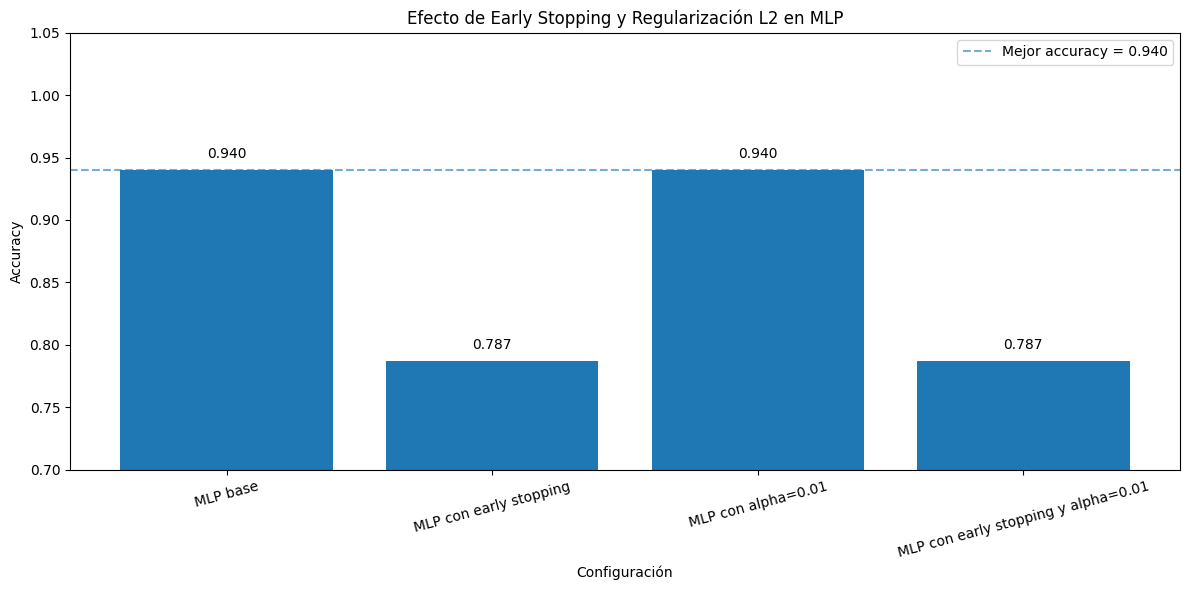

In [19]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    df_ej3["Modelo"],
    df_ej3["Accuracy"]
)

# Mostrar todas las barras
plt.ylim(0.70, 1.05)

plt.ylabel("Accuracy")
plt.xlabel("Configuración")
plt.title("Efecto de Early Stopping y Regularización L2 en MLP")

plt.xticks(rotation=15)

# Etiquetas encima de cada barra
for barra, valor in zip(bars, df_ej3["Accuracy"]):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 0.01,
        f"{valor:.3f}",
        ha="center",
        fontsize=10
    )

# Línea de referencia del mejor accuracy
plt.axhline(
    y=df_ej3["Accuracy"].max(),
    linestyle="--",
    alpha=0.6,
    label=f"Mejor accuracy = {df_ej3['Accuracy'].max():.3f}"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "comparacion_early_stopping_alpha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretación del Ejercicio 3

Se evaluó el efecto del parámetro `early_stopping` y de la regularización L2 mediante `alpha` sobre una red neuronal MLP.

Los resultados muestran que el modelo base alcanzó un accuracy de 0.94. Al incorporar regularización L2 con `alpha=0.01`, el rendimiento se mantuvo en 0.94, lo que indica que la regularización no afectó negativamente la capacidad predictiva del modelo.

Por otro lado, la activación de `early_stopping=True` redujo el accuracy a 0.787, tanto con como sin regularización. Esto sugiere que el entrenamiento se detuvo prematuramente, impidiendo que la red neuronal aprendiera adecuadamente la estructura del dataset.

En este problema, los mejores resultados se obtuvieron con el modelo base y con el modelo regularizado. Considerando que ambos alcanzaron el mismo accuracy, la configuración con `alpha=0.01` puede considerarse una alternativa adecuada al proporcionar regularización sin pérdida de rendimiento.

## Ejercicio 4

Para este ejercicio se utilizó el dataset Wine en lugar de `make_moons` o `make_circles`, porque estos últimos poseen solamente dos atributos y ya pueden representarse directamente en un plano.

El dataset Wine contiene 13 variables numéricas, por lo que resulta adecuado para aplicar Análisis de Componentes Principales (PCA) y reducir la información a dos componentes. De esta manera, es posible visualizar y comparar las fronteras de decisión de los modelos SVM y MLP en un espacio bidimensional.

In [20]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()

X_wine = wine.data
y_wine = wine.target

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine,
    y_wine,
    test_size=0.30,
    random_state=42,
    stratify=y_wine
)

scaler_w = StandardScaler()

X_train_w_s = scaler_w.fit_transform(X_train_w)
X_test_w_s = scaler_w.transform(X_test_w)

print("Dimensión original del entrenamiento:", X_train_w.shape)
print("Cantidad de clases:", len(wine.target_names))

Dimensión original del entrenamiento: (124, 13)
Cantidad de clases: 3


In [21]:
pca_w = PCA(n_components=2)

X_train_w_pca = pca_w.fit_transform(X_train_w_s)
X_test_w_pca = pca_w.transform(X_test_w_s)

varianza_explicada = pca_w.explained_variance_ratio_
varianza_acumulada = varianza_explicada.sum()

print("Dimensión luego de PCA:", X_train_w_pca.shape)
print("Varianza explicada por PC1:", round(varianza_explicada[0], 4))
print("Varianza explicada por PC2:", round(varianza_explicada[1], 4))
print("Varianza explicada acumulada:", round(varianza_acumulada, 4))

Dimensión luego de PCA: (124, 2)
Varianza explicada por PC1: 0.3573
Varianza explicada por PC2: 0.1921
Varianza explicada acumulada: 0.5494


In [22]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

svm_wine = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

mlp_wine = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

svm_wine.fit(X_train_w_pca, y_train_w)
mlp_wine.fit(X_train_w_pca, y_train_w)

pred_svm_wine = svm_wine.predict(X_test_w_pca)
pred_mlp_wine = mlp_wine.predict(X_test_w_pca)

acc_svm_wine = accuracy_score(y_test_w, pred_svm_wine)
acc_mlp_wine = accuracy_score(y_test_w, pred_mlp_wine)

print("Accuracy SVM con PCA:", round(acc_svm_wine, 4))
print("Accuracy MLP con PCA:", round(acc_mlp_wine, 4))

Accuracy SVM con PCA: 0.963
Accuracy MLP con PCA: 0.9259


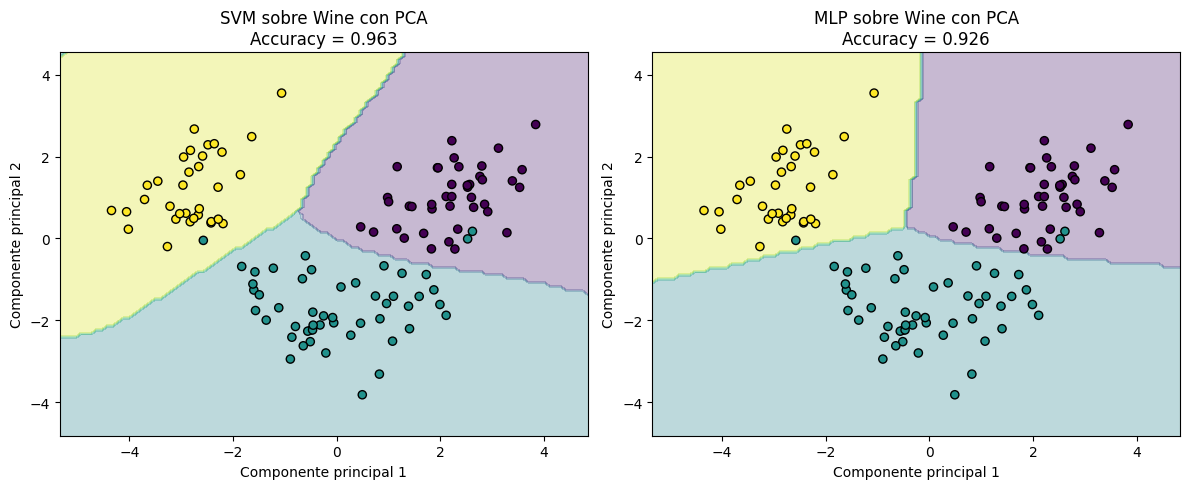

In [23]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

DecisionBoundaryDisplay.from_estimator(
    svm_wine,
    X_train_w_pca,
    ax=axes[0],
    alpha=0.3
)

axes[0].scatter(
    X_train_w_pca[:, 0],
    X_train_w_pca[:, 1],
    c=y_train_w,
    edgecolor="k",
    s=35
)

axes[0].set_title(
    f"SVM sobre Wine con PCA\nAccuracy = {acc_svm_wine:.3f}"
)

axes[0].set_xlabel("Componente principal 1")
axes[0].set_ylabel("Componente principal 2")

DecisionBoundaryDisplay.from_estimator(
    mlp_wine,
    X_train_w_pca,
    ax=axes[1],
    alpha=0.3
)

axes[1].scatter(
    X_train_w_pca[:, 0],
    X_train_w_pca[:, 1],
    c=y_train_w,
    edgecolor="k",
    s=35
)

axes[1].set_title(
    f"MLP sobre Wine con PCA\nAccuracy = {acc_mlp_wine:.3f}"
)

axes[1].set_xlabel("Componente principal 1")
axes[1].set_ylabel("Componente principal 2")

plt.tight_layout()

plt.savefig(
    "fronteras_wine_pca_svm_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Para este ejercicio se utilizó el Wine Dataset de scikit-learn, ya que posee 13 variables predictoras. Esto permite aplicar PCA para reducir la dimensionalidad a dos componentes principales y visualizar las fronteras de decisión de SVM y MLP en un espacio bidimensional. Los datasets moons y circles ya tienen únicamente dos atributos, por lo que PCA no aporta una reducción adicional de dimensiones

## Interpretación del Ejercicio 4

Se utilizó el dataset Wine, que contiene 13 variables predictoras, por lo que fue posible aplicar Análisis de Componentes Principales (PCA) para reducir la dimensionalidad a dos componentes.

La primera componente principal explicó el 35.73% de la variabilidad de los datos y la segunda componente explicó el 19.21%, alcanzando una varianza acumulada de 54.94%.

Tras proyectar los datos en dos dimensiones, se entrenaron un modelo SVM y una red neuronal MLP. El modelo SVM obtuvo un accuracy de 0.963, mientras que el modelo MLP alcanzó un accuracy de 0.926.

Las fronteras de decisión muestran que ambos modelos logran separar adecuadamente las tres clases del dataset. Sin embargo, el SVM presentó un mejor desempeño sobre el conjunto de prueba, lo que indica una mayor capacidad de clasificación en el espacio proyectado por PCA.

## Ejercicio 5

In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("===== REPORTE SVM =====")
print(
    classification_report(
        y_test_w,
        pred_svm_wine,
        target_names=wine.target_names
    )
)

print("\n===== REPORTE MLP =====")
print(
    classification_report(
        y_test_w,
        pred_mlp_wine,
        target_names=wine.target_names
    )
)

===== REPORTE SVM =====
              precision    recall  f1-score   support

     class_0       0.94      0.94      0.94        18
     class_1       0.95      0.95      0.95        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.96        54
   macro avg       0.97      0.97      0.97        54
weighted avg       0.96      0.96      0.96        54


===== REPORTE MLP =====
              precision    recall  f1-score   support

     class_0       0.94      0.89      0.91        18
     class_1       0.87      0.95      0.91        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.93        54
   macro avg       0.94      0.92      0.93        54
weighted avg       0.93      0.93      0.93        54



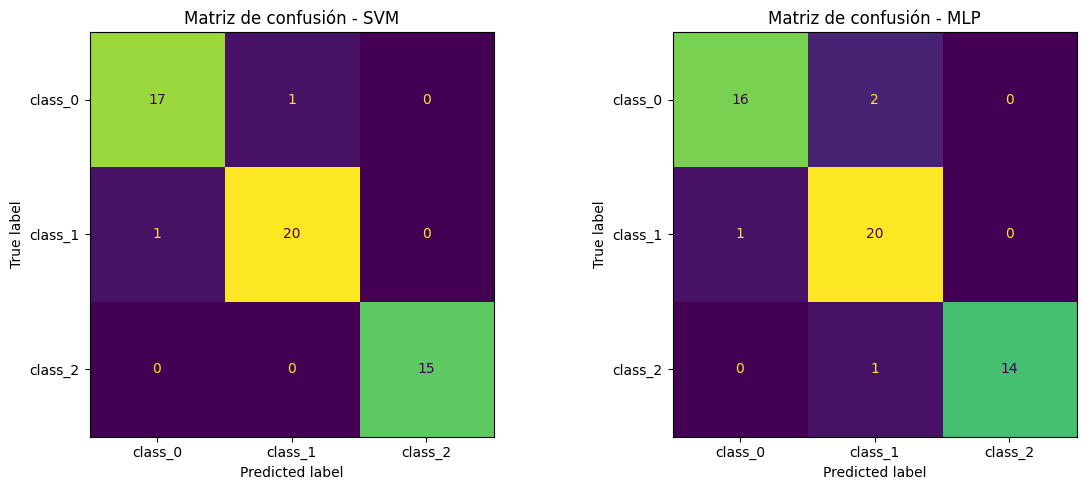

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_w,
    pred_svm_wine,
    display_labels=wine.target_names,
    ax=axes[0],
    colorbar=False
)

axes[0].set_title("Matriz de confusión - SVM")

ConfusionMatrixDisplay.from_predictions(
    y_test_w,
    pred_mlp_wine,
    display_labels=wine.target_names,
    ax=axes[1],
    colorbar=False
)

axes[1].set_title("Matriz de confusión - MLP")

plt.tight_layout()

plt.savefig(
    "matrices_confusion_svm_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Análisis de las matrices de confusión

En las matrices de confusión, los valores ubicados sobre la diagonal principal representan las observaciones clasificadas correctamente, mientras que los valores fuera de la diagonal corresponden a errores de clasificación.

Los colores más intensos sobre la diagonal indican una mayor cantidad de predicciones correctas. En el modelo SVM se observa una diagonal más marcada, lo que refleja un mejor desempeño general. Particularmente, la clase_2 fue clasificada correctamente en todos los casos.

En el modelo MLP también se observa una buena capacidad de clasificación; sin embargo, aparecen más errores fuera de la diagonal. La mayoría de las confusiones se producen entre las clases class_0 y class_1, mientras que la clase_2 mantiene un desempeño elevado.

Visualmente, la matriz de confusión del SVM presenta una mayor concentración de observaciones en la diagonal principal y menos valores fuera de ella, lo que coincide con sus mejores métricas de accuracy, precision, recall y F1-score.

In [26]:
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

resumen = pd.DataFrame({
    "Modelo": ["SVM", "MLP"],
    "Accuracy": [
        accuracy_score(y_test_w, pred_svm_wine),
        accuracy_score(y_test_w, pred_mlp_wine)
    ],
    "Precision": [
        precision_score(
            y_test_w,
            pred_svm_wine,
            average="weighted"
        ),
        precision_score(
            y_test_w,
            pred_mlp_wine,
            average="weighted"
        )
    ],
    "Recall": [
        recall_score(
            y_test_w,
            pred_svm_wine,
            average="weighted"
        ),
        recall_score(
            y_test_w,
            pred_mlp_wine,
            average="weighted"
        )
    ],
    "F1-score": [
        f1_score(
            y_test_w,
            pred_svm_wine,
            average="weighted"
        ),
        f1_score(
            y_test_w,
            pred_mlp_wine,
            average="weighted"
        )
    ]
})

resumen

,Modelo,Accuracy,Precision,Recall,F1-score
0,SVM,0.962963,0.962963,0.962963,0.962963
1,MLP,0.925926,0.929668,0.925926,0.926496


## Interpretación del Ejercicio 5

Se realizó una comparación cuantitativa entre los modelos SVM y MLP utilizando el dataset Wine proyectado mediante PCA.

El modelo SVM obtuvo un accuracy de 0.963, junto con valores de precision, recall y F1-score de aproximadamente 0.963. Por su parte, el modelo MLP alcanzó un accuracy de 0.926, con valores de precision, recall y F1-score cercanos a 0.926.

Las matrices de confusión muestran que ambos modelos clasificaron correctamente la mayoría de las observaciones. Sin embargo, el SVM cometió únicamente dos errores

## Conclusiones

En este trabajo se compararon modelos SVM con kernel RBF y redes neuronales MLP sobre distintos conjuntos de datos no lineales. Los resultados mostraron que ambos modelos son capaces de representar fronteras complejas, aunque el desempeño depende de la elección de hiperparámetros y arquitectura. En el dataset moons, la búsqueda de hiperparámetros permitió identificar configuraciones competitivas para SVM. En circles, la arquitectura MLP con una capa oculta de 50 neuronas presentó la mejor capacidad de generalización. La regularización L2 mantuvo el rendimiento del modelo, mientras que early stopping redujo la exactitud al detener el entrenamiento antes de alcanzar la convergencia. Finalmente, en el dataset Wine reducido mediante PCA, SVM obtuvo el mejor desempeño global, alcanzando una exactitud de 0.963 frente a 0.926 de MLP. Los resultados muestran la importancia de ajustar adecuadamente los modelos y seleccionar la complejidad necesaria para cada problema.